# Hands-on DeepFace #1 – Face Verification

This notebook:
1. Installs required libraries
2. Downloads the FaceScrub dataset
3. Creates database and validation image folders
4. Performs face verification using DeepFace


In [ ]:
import os, gdown, zipfile

url = 'https://github.com/theothings/facescrub-dataset/archive/refs/heads/master.zip'
output = 'facescrub.zip'

if not os.path.exists(output):
    gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall()

print('Dataset downloaded')

In [ ]:
import os
import random
import shutil

dataset_path = "facescrub-dataset-master"
database_path = "database"
validation_path = "validation"

os.makedirs(database_path, exist_ok=True)
os.makedirs(validation_path, exist_ok=True)

max_people = 100
processed = 0

image_extensions = (".jpg", ".jpeg", ".png")

for root, dirs, files in os.walk(dataset_path):

    images = [f for f in files if f.lower().endswith(image_extensions)]

    if len(images) < 12:
        continue

    random.shuffle(images)

    db_imgs = images[:6]
    val_imgs = images[6:12]

    actor = os.path.basename(root)

    for img in db_imgs:
        try:
            src = os.path.join(root, img)
            dst = os.path.join(database_path, actor + "_" + img)
            shutil.copy(src, dst)
        except Exception:
            continue

    for img in val_imgs:
        try:
            src = os.path.join(root, img)
            dst = os.path.join(validation_path, actor + "_" + img)
            shutil.copy(src, dst)
        except Exception:
            continue

    processed += 1

    if processed >= max_people:
        break

print("Images prepared successfully!")
print("Database images:", len(os.listdir(database_path)))
print("Validation images:", len(os.listdir(validation_path)))

In [ ]:
import random
from deepface import DeepFace

database_images = os.listdir(database_path)
validation_images = os.listdir(validation_path)

img1_path = os.path.join(database_path, random.choice(database_images))
img2_path = os.path.join(validation_path, random.choice(validation_images))

print(img1_path)
print(img2_path)

result = DeepFace.verify(img1_path, img2_path, model_name='VGG-Face', distance_metric='cosine')
print(result)

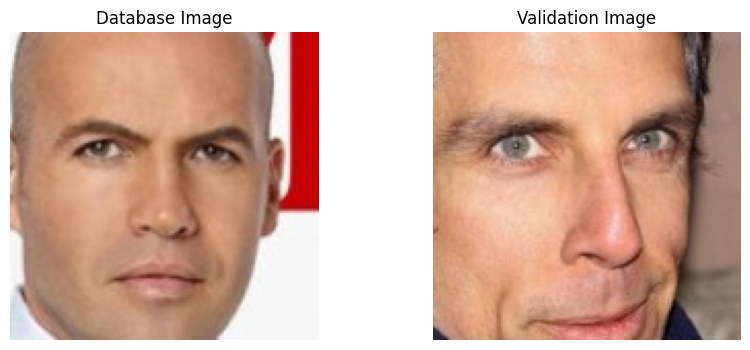

In [5]:
import cv2, matplotlib.pyplot as plt

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title('Database Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title('Validation Image')
plt.axis('off')

plt.show()